In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
df = pd.read_csv("tabula-pv_resultats_sp_info1.csv")


In [3]:
df.head()

,N°,Ident.,Nom,Prenom,UE.1.1,UE.1.2,UE.1.3,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
0,NaN,NaN,NaN,NaN,ccV01,exV01,moyV01,ccV02,exV02,moyV02,ccV03,exV03,moyV03,ccV04,exV04,moyV04,ccV06
1,1,14712009,ABBASSI,AYA,"9,40","8,25","8,65","13,80","11,00","11,98","15,00","9,00","11,10","17,25","13,00","15,13","13,00"
2,2,15250422,ABDELLAOUI,HAYDER,"8,20","3,50","5,15","9,40","7,75","8,33","13,00","14,00","13,65","16,75","14,00","15,38","6,00"
3,3,14438881,ABDERRAZAK,CHAIMA,"15,60","19,50","18,14","10,60","10,00","10,21","15,50","16,00","15,83","14,75","14,75","14,75","11,50"
4,4,15255793,ABDOULI,MAYSSA,"5,00","8,00","6,95","12,60","9,25","10,42","9,00","14,00","12,25","17,50","16,25","16,88","14,00"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 659 entries, 0 to 658
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   N°           647 non-null    object
 1   Ident.       647 non-null    object
 2   Nom          647 non-null    object
 3   Prenom       647 non-null    object
 4   UE.1.1       657 non-null    object
 5   UE.1.2       653 non-null    object
 6   UE.1.3       655 non-null    object
 7   Unnamed: 7   648 non-null    object
 8   Unnamed: 8   648 non-null    object
 9   Unnamed: 9   648 non-null    object
 10  Unnamed: 10  648 non-null    object
 11  Unnamed: 11  540 non-null    object
 12  Unnamed: 12  540 non-null    object
 13  Unnamed: 13  540 non-null    object
 14  Unnamed: 14  540 non-null    object
 15  Unnamed: 15  540 non-null    object
 16  Unnamed: 16  540 non-null    object
dtypes: object(17)
memory usage: 87.6+ KB


## **Cleaning w Merging**

In [5]:
df.columns = df.columns.str.strip()
df = df.dropna(axis=1, how='all')
df = df.dropna(subset=["Ident."])
df.drop("N°",axis=1,inplace=True)
df[["Ident.", "Prenom", "Nom"]] = df[["Ident.", "Prenom", "Nom"]].fillna(method="ffill")

In [6]:
df['row_number'] = df.groupby('Ident.').cumcount()
grade_blocks = []
unique_row_counts = df['row_number'].max() + 1
for i in range(unique_row_counts):
    block = df[df['row_number'] == i].copy()
    grade_cols = [col for col in block.columns if col not in ["Ident.", "Prenom", "Nom", 'row_number']]
    block.rename(columns={col: f'Block{i+1}_{col}' for col in grade_cols}, inplace=True)
    block = block.drop(columns=['row_number'])
    grade_blocks.append(block)
from functools import reduce
merged_df = reduce(lambda left, right: pd.merge(left, right, on=["Ident.", "Prenom", "Nom"], how='outer'), grade_blocks)
merged_df = merged_df.iloc[:, :75]

## **Data Manipulation**

In [7]:
merged_df.columns=['Ident.','Nom','Prenom','cc_math_ing', 'exam_math_ing','moy_math_ing','cc_analyse_s1', 'exam_analyse_s1','moy_analyse_s1','cc_algo', 'exam_algo','moy_algo','cc_prog', 'exam_prog','moy_prog','cc_TIC', 'exam_TIC','moy_TIC','cc_logique', 'exam_logique','moy_logique','cc_GL', 'exam_GL','moy_GL','cc_circuit', 'exam_circuit','moy_circuit','cc_semi', 'exam_semi','moy_semi','cc_eco_s1', 'exam_eco_s1','moy_eco_s1','cc_ang_s1', 'exam_ang_s1','moy_ang_s1','cc_fr_s1', 'exam_fr_s1','moy_fr_s1','cc_proba/stat', 'exam_proba/stat','moy_proba/stat','cc_analyse_s2', 'exam_analyse_s2','moy_analyse_s2','cc_structure', 'exam_structure','moy_structure','cc_POO', 'exam_POO','moy_POO','cc_archi', 'exam_archi','moy_archi','cc_reseau', 'exam_reseau','moy_reseau','cc_web', 'exam_web','moy_web','cc_BD', 'exam_BD','moy_BD','cc_conception', 'exam_conception','moy_conception','cc_eco_s2', 'exam_eco_s2','moy_eco_s2','cc_ang_s2', 'exam_ang_s2','moy_ang_s2','cc_fr_s2', 'exam_fr_s2','moy_fr_s2']
merged_df.sort_values('Nom',inplace=True)
merged_df.reset_index(drop=True,inplace=True)

In [8]:
for col in merged_df.columns[3:]:
    merged_df[col] = pd.to_numeric(merged_df[col].astype(str).str.replace(',', '.'), errors='coerce')

In [9]:
coef_math_ing = 3
coef_analyse_s1 = 2
coef_algo = 3
coef_prog = 4
coef_TIC = 2
coef_logique = 3
coef_GL = 3
coef_circuit = 3
coef_semi = 2
coef_eco_s1 = 2
coef_ang_s1 = 1.5
coef_fr_s1 = 1.5
coef_eco_s2 = 2
coef_ang_s2 = 1.5
coef_fr_s2 = 1.5
coef_proba_stat = 3
coef_analyse_s2 = 2
coef_structure = 2.5
coef_POO = 4
coef_archi = 2.5
coef_reseau = 2.5
coef_conception = 3.5
coef_BD = 2.5
coef_web = 2.5

merged_df['moyenne_annuelle'] = ((merged_df['moy_math_ing'] * coef_math_ing +merged_df['moy_analyse_s1'] * coef_analyse_s1 +merged_df['moy_algo'] * coef_algo +merged_df['moy_prog'] * coef_prog +merged_df['moy_TIC'] * coef_TIC +merged_df['moy_logique'] * coef_logique +merged_df['moy_GL'] * coef_GL +merged_df['moy_circuit'] * coef_circuit +merged_df['moy_semi'] * coef_semi +merged_df['moy_eco_s1'] * coef_eco_s1 +merged_df['moy_ang_s1'] * coef_ang_s1 +merged_df['moy_fr_s1'] * coef_fr_s1 +merged_df['moy_proba/stat'] * coef_proba_stat +merged_df['moy_analyse_s2'] * coef_analyse_s2 +merged_df['moy_structure'] * coef_structure +merged_df['moy_POO'] * coef_POO +merged_df['moy_archi'] * coef_archi +merged_df['moy_reseau'] * coef_reseau +merged_df['moy_eco_s2'] * coef_eco_s2 +merged_df['moy_fr_s2'] * coef_fr_s2 +merged_df['moy_ang_s2'] * coef_ang_s2 +merged_df['moy_conception'] * coef_conception +merged_df['moy_web'] * coef_web  +merged_df['moy_BD'] * coef_BD )/(coef_math_ing + coef_analyse_s1 + coef_algo + coef_prog + coef_TIC + coef_logique + coef_GL + coef_circuit + coef_semi + coef_eco_s1 + coef_ang_s1 + coef_fr_s1 + coef_proba_stat + coef_analyse_s2 + coef_structure + coef_POO + coef_archi + coef_reseau + coef_BD + coef_conception + coef_ang_s2 +  coef_eco_s2 + coef_fr_s2 + coef_web)).round(2)

merged_df

,Ident.,Nom,Prenom,cc_math_ing,exam_math_ing,moy_math_ing,cc_analyse_s1,exam_analyse_s1,moy_analyse_s1,cc_algo,exam_algo,moy_algo,cc_prog,exam_prog,moy_prog,cc_TIC,exam_TIC,moy_TIC,cc_logique,exam_logique,moy_logique,cc_GL,exam_GL,moy_GL,cc_circuit,exam_circuit,moy_circuit,cc_semi,exam_semi,moy_semi,cc_eco_s1,exam_eco_s1,moy_eco_s1,cc_ang_s1,exam_ang_s1,moy_ang_s1,cc_fr_s1,exam_fr_s1,moy_fr_s1,cc_proba/stat,exam_proba/stat,moy_proba/stat,cc_analyse_s2,exam_analyse_s2,moy_analyse_s2,cc_structure,exam_structure,moy_structure,cc_POO,exam_POO,moy_POO,cc_archi,exam_archi,moy_archi,cc_reseau,exam_reseau,moy_reseau,cc_web,exam_web,moy_web,cc_BD,exam_BD,moy_BD,cc_conception,exam_conception,moy_conception,cc_eco_s2,exam_eco_s2,moy_eco_s2,cc_ang_s2,exam_ang_s2,moy_ang_s2,cc_fr_s2,exam_fr_s2,moy_fr_s2,moyenne_annuelle
0,14712009,ABBASSI,AYA,9.4,8.25,8.65,13.8,11.00,11.98,15.0,9.0,11.10,17.25,13.00,15.13,13.0,17.5,15.93,15.8,12.0,13.33,13.50,11.50,12.20,16.00,10.00,12.10,13.0,9.5,10.73,12.0,6.5,8.43,16.0,15.50,15.68,17.5,12.0,13.93,10.40,8.00,8.84,14.2,11.50,12.45,14.00,11.5,12.38,17.25,16.0,16.63,16.00,12.50,13.73,10.50,9.50,9.85,15.5,11.75,13.06,14.00,8.00,10.10,13.00,14.00,13.65,15.0,9.0,11.10,16.0,12.75,13.89,16.0,13.0,14.05,12.48
1,15250422,ABDELLAOUI,HAYDER,8.2,3.50,5.15,9.4,7.75,8.33,13.0,14.0,13.65,16.75,14.00,15.38,6.0,14.0,11.20,15.0,11.5,12.73,17.00,14.75,15.54,18.50,15.25,16.39,6.0,15.0,11.85,17.0,10.0,12.45,15.0,12.75,13.54,18.0,13.0,14.75,12.20,8.50,9.80,14.1,6.75,9.32,15.50,11.5,12.90,20.00,16.0,18.00,12.00,16.50,14.93,14.50,16.50,15.80,20.0,15.00,16.75,15.75,10.00,12.01,17.25,12.00,13.84,14.0,8.0,10.10,14.0,10.50,11.73,18.0,16.0,16.70,13.24
2,14438881,ABDERRAZAK,CHAIMA,15.6,19.50,18.14,10.6,10.00,10.21,15.5,16.0,15.83,14.75,14.75,14.75,11.5,14.5,13.45,18.3,14.5,15.83,15.25,10.75,12.33,18.65,15.50,16.60,17.5,11.0,13.28,10.0,17.5,14.88,16.0,16.00,16.00,17.0,13.5,14.73,18.25,15.25,16.30,12.5,12.50,12.50,12.00,13.5,12.98,18.50,14.5,16.50,5.50,11.50,9.40,11.00,16.00,14.25,20.0,19.50,19.68,12.50,12.00,12.18,17.25,10.00,12.54,13.0,14.5,13.98,16.0,15.25,15.51,19.0,16.0,17.05,14.61
3,15255793,ABDOULI,MAYSSA,5.0,8.00,6.95,12.6,9.25,10.42,9.0,14.0,12.25,17.50,16.25,16.88,14.0,13.0,13.35,15.5,13.5,14.20,17.00,10.00,12.45,15.50,15.25,15.34,14.0,11.0,12.05,16.0,13.0,14.05,16.0,13.25,14.21,16.0,13.5,14.38,14.80,9.75,11.52,12.2,6.00,8.17,12.50,10.5,11.20,19.00,18.0,18.50,7.00,11.50,9.93,10.00,9.50,9.68,15.0,17.50,16.63,16.50,8.50,11.30,12.75,13.00,12.91,14.0,11.0,12.05,15.0,12.25,13.21,18.0,13.5,15.08,12.95
4,12369773,ABIDI,MOHAMED,10.0,2.75,5.29,6.0,2.00,3.40,4.0,3.0,3.35,16.75,6.00,11.38,6.5,4.0,4.88,10.0,11.0,10.65,16.00,8.25,10.96,16.70,5.00,9.10,7.0,5.0,5.70,17.0,4.0,8.55,13.0,16.00,14.95,15.0,13.0,13.70,8.00,7.00,7.35,6.2,4.75,5.26,1.00,8.5,5.88,12.00,10.0,11.00,6.25,7.50,7.06,15.00,9.00,11.10,17.5,11.50,13.60,7.00,3.50,4.73,13.50,11.00,11.88,13.0,10.0,11.05,14.0,16.50,15.63,17.0,14.0,15.05,9.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,11993744,TRABELSI,MOHAMED,11.4,8.00,9.19,5.6,8.50,7.49,12.5,12.0,12.18,14.00,6.50,10.25,3.5,2.0,2.53,10.0,11.0,10.65,15.50,5.50,9.00,11.80,6.50,8.36,4.0,4.0,4.00,12.0,5.0,7.45,16.0,15.50,15.68,16.0,14.0,14.70,11.50,0.00,4.03,6.4,0.00,2.24,1.00,0.0,0.35,3.00,0.0,1.50,3.25,1.50,2.11,1.75,0.00,0.61,18.0,0.00,6.30,2.00,2.00,2.00,10.50,3.50,5.95,10.0,4.0,6.10,16.0,14.00,14.70,16.0,15.0,15.35,6.78
103,13512731,YAHYA,GHOFRANE,12.3,10.50,11.13,13.4,13.75,13.63,15.5,5.0,8.68,17.50,7.75,12.63,13.0,15.0,14.30,17.6,13.5,14.94,15.00,10.50,12.08,18.50,15.00,16.23,18.0,8.5,11.83,10.0,4.0,6.10,16.0,14.00,14.70,18.0,14.5,15.73,13.20,9.75,10.96,9.1,12.00,10.99,10.50,7.0,8.23,17.50,10.0,13.75,14.00,10.25,11.56,9.50,13.75,12.26,14.5,16.75,15.96,6.25,9.50,

In [10]:
Classe_A=pd.read_csv('Classe_A.csv')
Classe_A["Classe"]="A"
Classe_A.drop(columns="N°",inplace=True)
Classe_B=pd.read_csv('Classe_B.csv')
Classe_B["Classe"]="B"
Classe_B.drop(columns="N°",inplace=True)
Classe_C=pd.read_csv('Classe_C.csv')
Classe_C["Classe"]="C"
Classe_C.drop(columns="N°",inplace=True)
Classe_D=pd.read_csv('Classe_D.csv')
Classe_D["Classe"]="D"
Classe_D.drop(columns="N°",inplace=True)
Classes=pd.concat([Classe_A,Classe_B,Classe_C,Classe_D])
Classes.reset_index(drop=True,inplace=True)
Classes.columns=['Nom','Prenom','Classe']
Classes['Nom']=Classes['Nom'].str.upper()
Classes['Prenom']=Classes['Prenom'].str.upper()

In [11]:
merged_df.loc[77,'Nom']="LTAYEF"
merged_df.loc[19,'Prenom']="MOHAMED CHAKER"
merged_df.loc[61,'Prenom']="SAAD EDDINE"
merged_df.loc[67,'Prenom']="BARAA"
merged_df.loc[82,'Prenom']="MOHAMED HOSNI"
merged_df.loc[104,'Prenom']="HOUSSEM EDDINE"
merged_df.loc[8,['Nom','Prenom']]=["ATIG","ABDERAHMEN"]
merged_df.loc[27,'Nom']="BENOTHMEN"
merged_df.loc[47,'Prenom']="MOUHIB"
merged_df.loc[48,'Prenom']="ISLEM"
merged_df.loc[55,'Prenom']="ABDERRAHMEN"
merged_df.loc[76,'Prenom']="AHMED YASSINE"
merged_df.loc[96,'Prenom']="MOHAMED AZIZ"
merged_df.loc[102,'Prenom']="MOHAMED ALI"
merged_df.loc[14,['Nom','Prenom']]=["ABDELHAKIM","BARBARIA"]
merged_df.loc[4,'Prenom']="MOHAMED DHIA ALISLEM"
merged_df.loc[70,'Prenom']="MOHAMED AMINE"
merged_df.loc[88,'Nom']="OULEDOUHIBA"
merged_df.loc[89,'Prenom']="MOHAMED AMINE"
merged_df.loc[93,'Prenom']="BACEM"
merged_df.loc[17,'Prenom']="MOHAMMED BAYREM"
merged_df.loc[24,'Prenom']="MOHAMED ESSEDIK"
merged_df.loc[26,'Nom']="BEN TAHER"
merged_df.loc[63,'Prenom']="MOHAMED AMIN"
merged_df.loc[78,'Prenom']="MOHAMED MOUNIB"
merged_df.loc[84,'Prenom']="MOHAMED ALI"
merged_df.loc[91,'Prenom']="MOHAMED AZIZ"
merged_df.loc[95,'Prenom']="MAKREM"
info_1ere=merged_df.merge(Classes,on=['Nom','Prenom'])
info_1ere

,Ident.,Nom,Prenom,cc_math_ing,exam_math_ing,moy_math_ing,cc_analyse_s1,exam_analyse_s1,moy_analyse_s1,cc_algo,exam_algo,moy_algo,cc_prog,exam_prog,moy_prog,cc_TIC,exam_TIC,moy_TIC,cc_logique,exam_logique,moy_logique,cc_GL,exam_GL,moy_GL,cc_circuit,exam_circuit,moy_circuit,cc_semi,exam_semi,moy_semi,cc_eco_s1,exam_eco_s1,moy_eco_s1,cc_ang_s1,exam_ang_s1,moy_ang_s1,cc_fr_s1,exam_fr_s1,moy_fr_s1,cc_proba/stat,exam_proba/stat,moy_proba/stat,cc_analyse_s2,exam_analyse_s2,moy_analyse_s2,cc_structure,exam_structure,moy_structure,cc_POO,exam_POO,moy_POO,cc_archi,exam_archi,moy_archi,cc_reseau,exam_reseau,moy_reseau,cc_web,exam_web,moy_web,cc_BD,exam_BD,moy_BD,cc_conception,exam_conception,moy_conception,cc_eco_s2,exam_eco_s2,moy_eco_s2,cc_ang_s2,exam_ang_s2,moy_ang_s2,cc_fr_s2,exam_fr_s2,moy_fr_s2,moyenne_annuelle,Classe
0,14712009,ABBASSI,AYA,9.4,8.25,8.65,13.8,11.00,11.98,15.0,9.0,11.10,17.25,13.00,15.13,13.0,17.5,15.93,15.8,12.0,13.33,13.50,11.50,12.20,16.00,10.00,12.10,13.0,9.5,10.73,12.0,6.5,8.43,16.0,15.50,15.68,17.5,12.0,13.93,10.40,8.00,8.84,14.2,11.50,12.45,14.00,11.5,12.38,17.25,16.0,16.63,16.00,12.50,13.73,10.50,9.50,9.85,15.5,11.75,13.06,14.00,8.00,10.10,13.00,14.00,13.65,15.0,9.0,11.10,16.0,12.75,13.89,16.0,13.0,14.05,12.48,A
1,15250422,ABDELLAOUI,HAYDER,8.2,3.50,5.15,9.4,7.75,8.33,13.0,14.0,13.65,16.75,14.00,15.38,6.0,14.0,11.20,15.0,11.5,12.73,17.00,14.75,15.54,18.50,15.25,16.39,6.0,15.0,11.85,17.0,10.0,12.45,15.0,12.75,13.54,18.0,13.0,14.75,12.20,8.50,9.80,14.1,6.75,9.32,15.50,11.5,12.90,20.00,16.0,18.00,12.00,16.50,14.93,14.50,16.50,15.80,20.0,15.00,16.75,15.75,10.00,12.01,17.25,12.00,13.84,14.0,8.0,10.10,14.0,10.50,11.73,18.0,16.0,16.70,13.24,B
2,14438881,ABDERRAZAK,CHAIMA,15.6,19.50,18.14,10.6,10.00,10.21,15.5,16.0,15.83,14.75,14.75,14.75,11.5,14.5,13.45,18.3,14.5,15.83,15.25,10.75,12.33,18.65,15.50,16.60,17.5,11.0,13.28,10.0,17.5,14.88,16.0,16.00,16.00,17.0,13.5,14.73,18.25,15.25,16.30,12.5,12.50,12.50,12.00,13.5,12.98,18.50,14.5,16.50,5.50,11.50,9.40,11.00,16.00,14.25,20.0,19.50,19.68,12.50,12.00,12.18,17.25,10.00,12.54,13.0,14.5,13.98,16.0,15.25,15.51,19.0,16.0,17.05,14.61,C
3,15255793,ABDOULI,MAYSSA,5.0,8.00,6.95,12.6,9.25,10.42,9.0,14.0,12.25,17.50,16.25,16.88,14.0,13.0,13.35,15.5,13.5,14.20,17.00,10.00,12.45,15.50,15.25,15.34,14.0,11.0,12.05,16.0,13.0,14.05,16.0,13.25,14.21,16.0,13.5,14.38,14.80,9.75,11.52,12.2,6.00,8.17,12.50,10.5,11.20,19.00,18.0,18.50,7.00,11.50,9.93,10.00,9.50,9.68,15.0,17.50,16.63,16.50,8.50,11.30,12.75,13.00,12.91,14.0,11.0,12.05,15.0,12.25,13.21,18.0,13.5,15.08,12.95,B
4,12369773,ABIDI,MOHAMED DHIA ALISLEM,10.0,2.75,5.29,6.0,2.00,3.40,4.0,3.0,3.35,16.75,6.00,11.38,6.5,4.0,4.88,10.0,11.0,10.65,16.00,8.25,10.96,16.70,5.00,9.10,7.0,5.0,5.70,17.0,4.0,8.55,13.0,16.00,14.95,15.0,13.0,13.70,8.00,7.00,7.35,6.2,4.75,5.26,1.00,8.5,5.88,12.00,10.0,11.00,6.25,7.50,7.06,15.00,9.00,11.10,17.5,11.50,13.60,7.00,3.50,4.73,13.50,11.00,11.88,13.0,10.0,11.05,14.0,16.50,15.63,17.0,14.0,15.05,9.06,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,11993744,TRABELSI,MOHAMED ALI,11.4,8.00,9.19,5.6,8.50,7.49,12.5,12.0,12.18,14.00,6.50,10.25,3.5,2.0,2.53,10.0,11.0,10.65,15.50,5.50,9.00,11.80,6.50,8.36,4.0,4.0,4.00,12.0,5.0,7.45,16.0,15.50,15.68,16.0,14.0,14.70,11.50,0.00,4.03,6.4,0.00,2.24,1.00,0.0,0.35,3.00,0.0,1.50,3.25,1.50,2.11,1.75,0.00,0.61,18.0,0.00,6.30,2.00,2.00,2.00,10.50,3.50,5.95,10.0,4.0,6.10,16.0,14.00,14.70,16.0,15.0,15.35,6.78,D
102,13512731,YAHYA,GHOFRANE,12.3,10.50,11.13,13.4,13.75,13.63,15.5,5.0,8.68,17.50,7.75,12.63,13.0,15.0,14.30,17.6,13.5,14.94,15.00,10.50,12.08,18.50,15.00,16.23,18.0,8.5,11.83,10.0,4.0,6.10,16.0,14.00,14.70,18.0,14.5,15.73,13.20,9.75,10.96,9.1,12.00,10.99,10.50,7.0,8.23,17.50,10.0,13.75,14.00,10.25,11.56,9.50

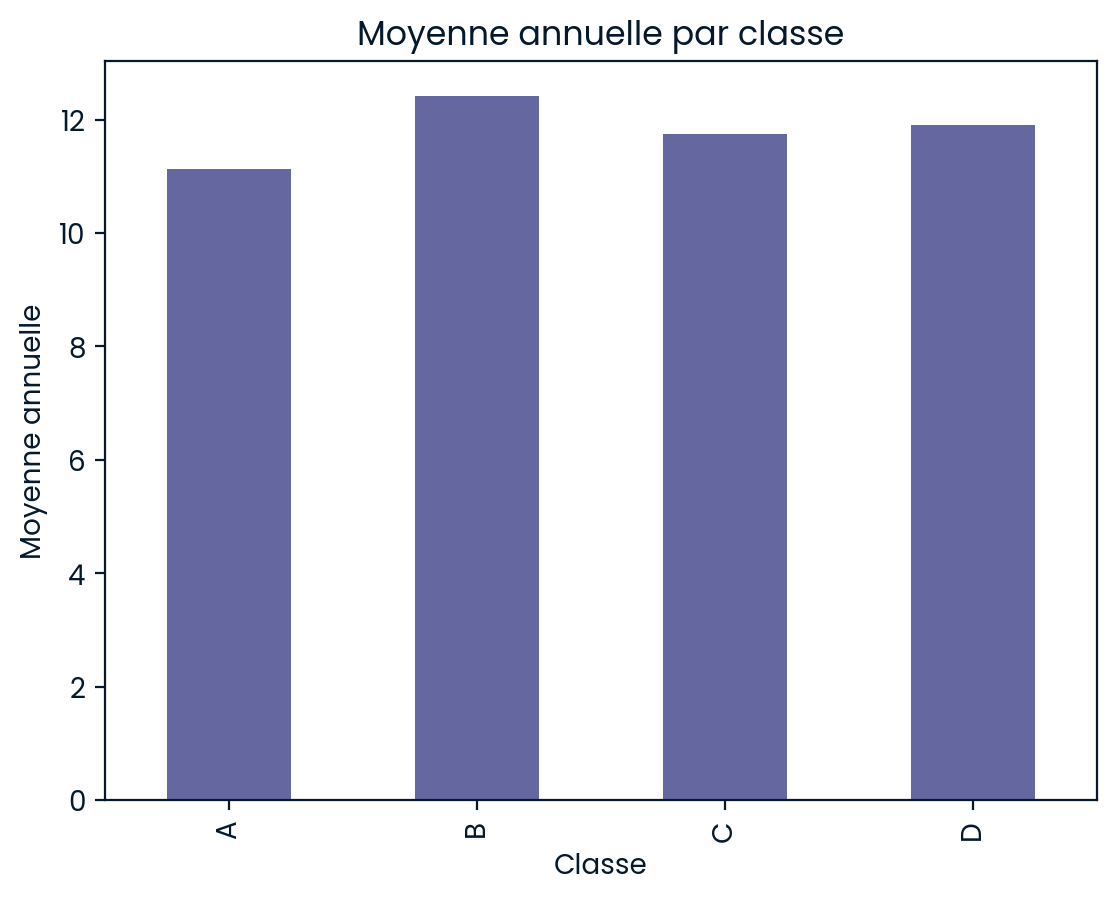

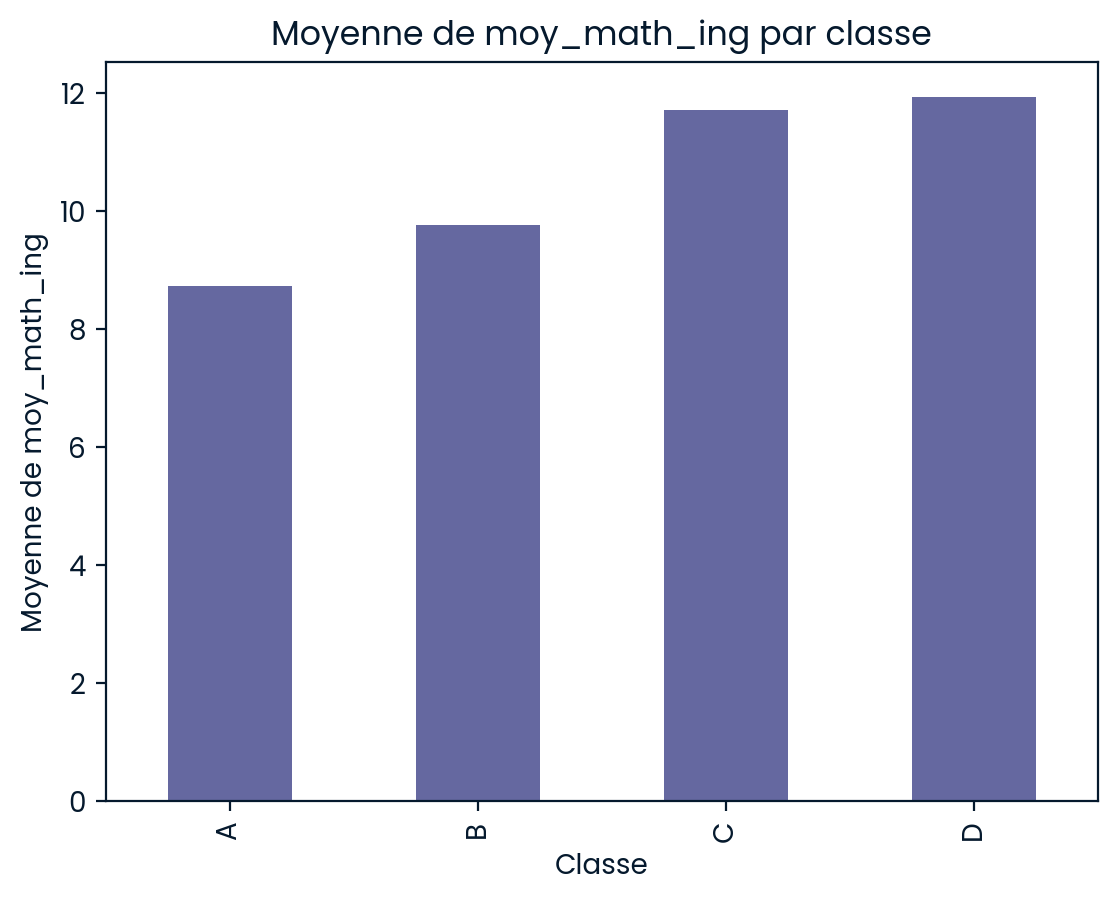

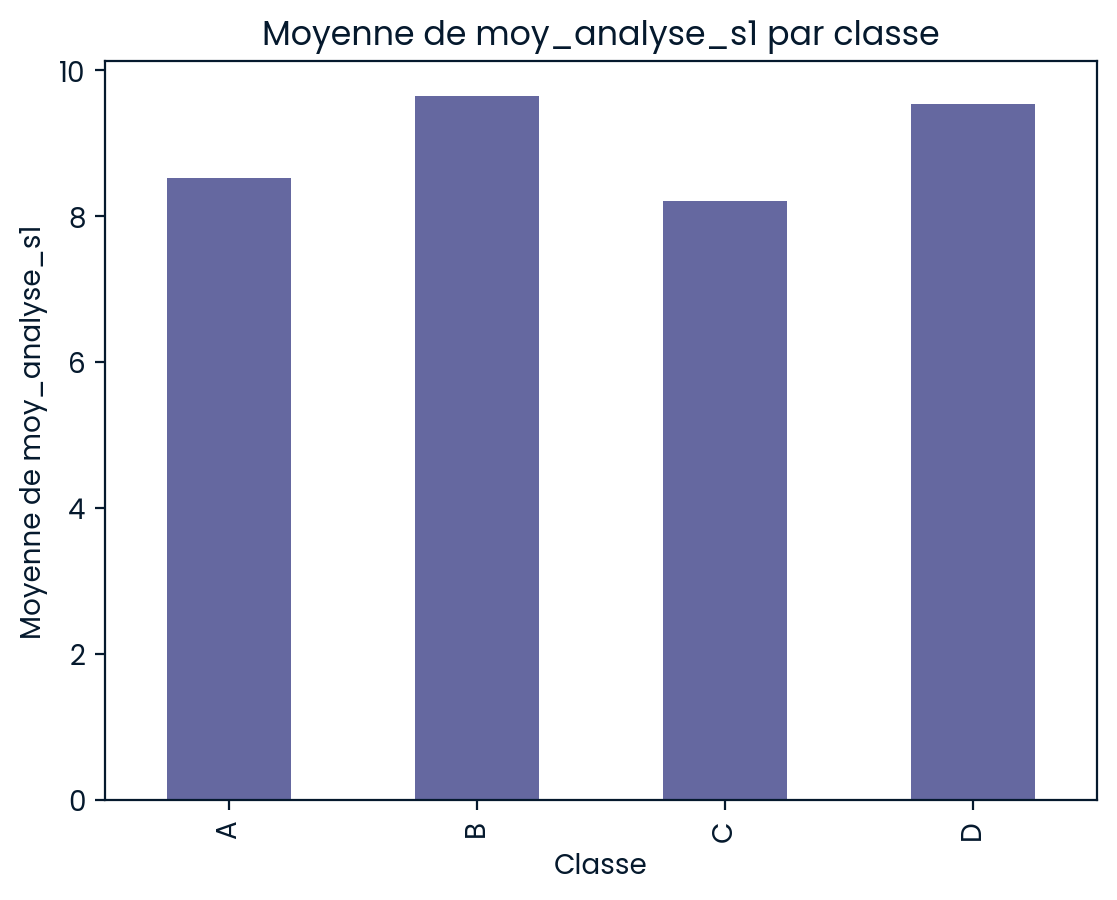

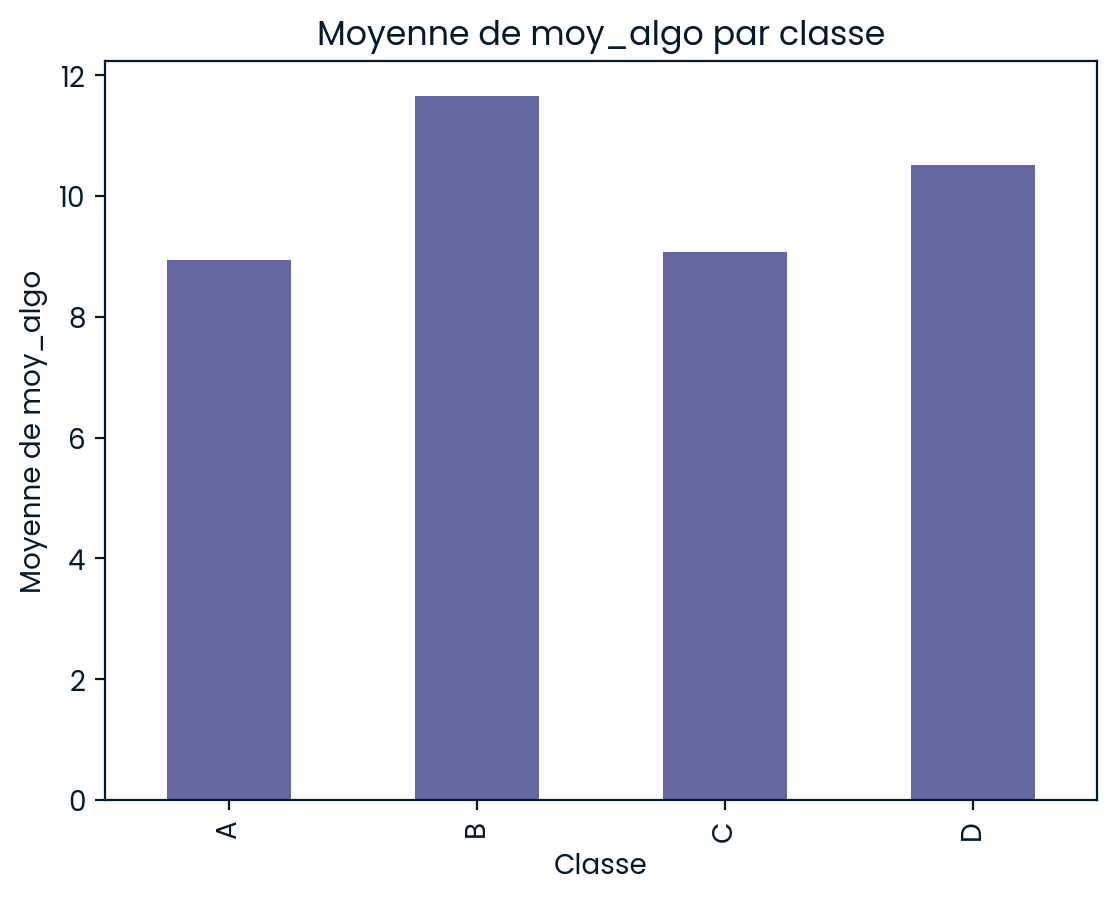

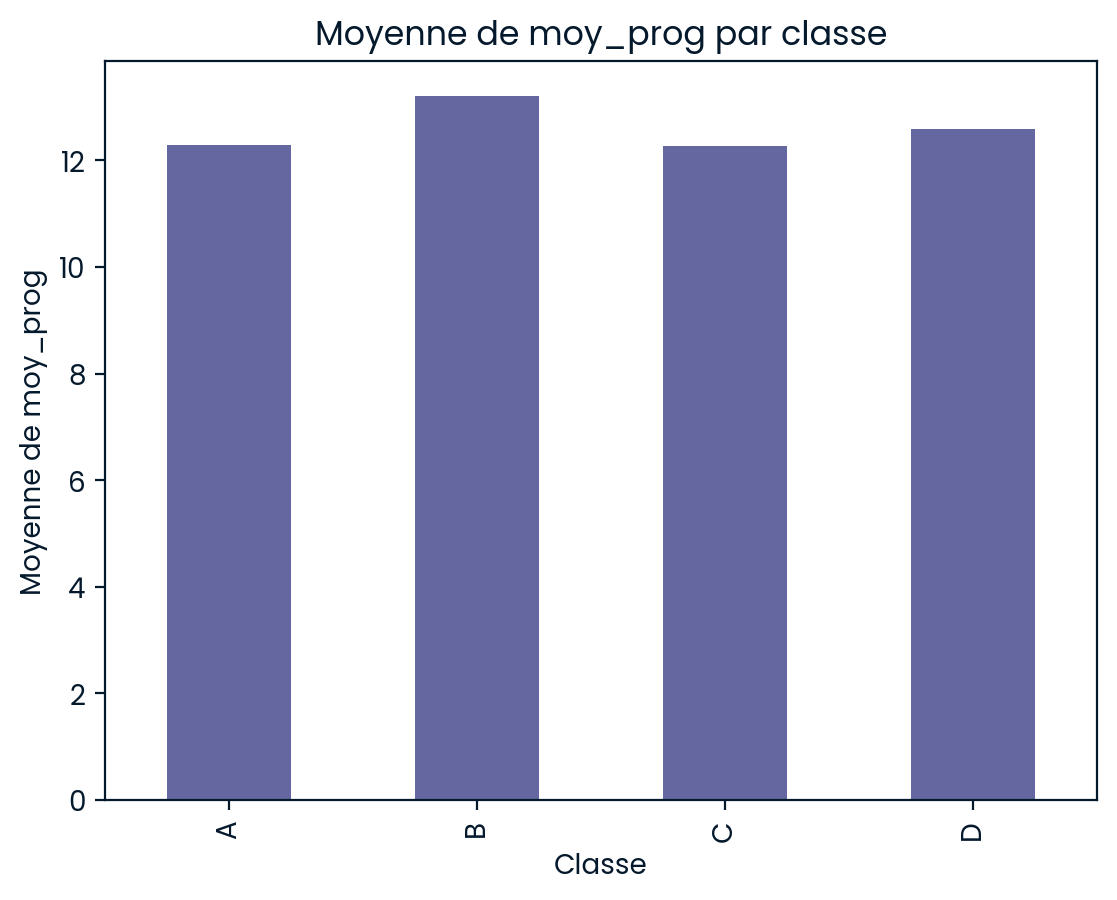

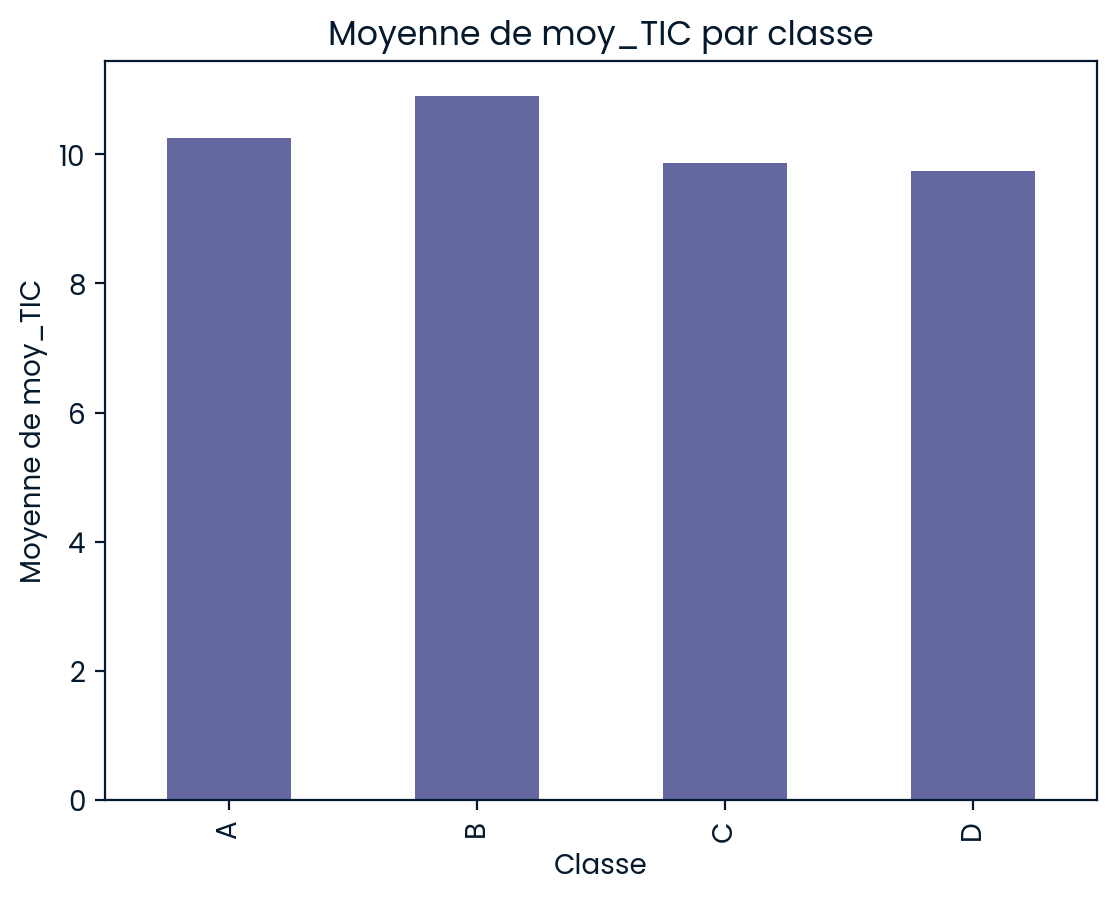

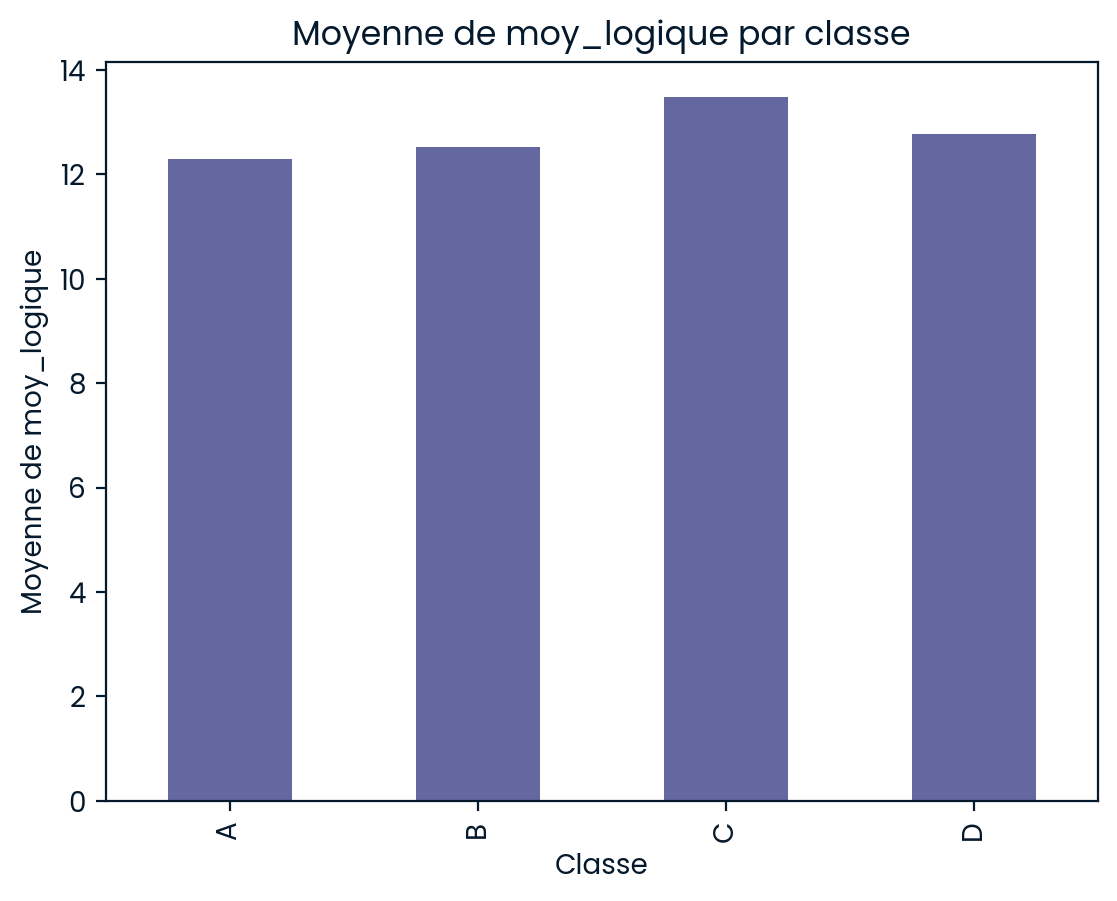

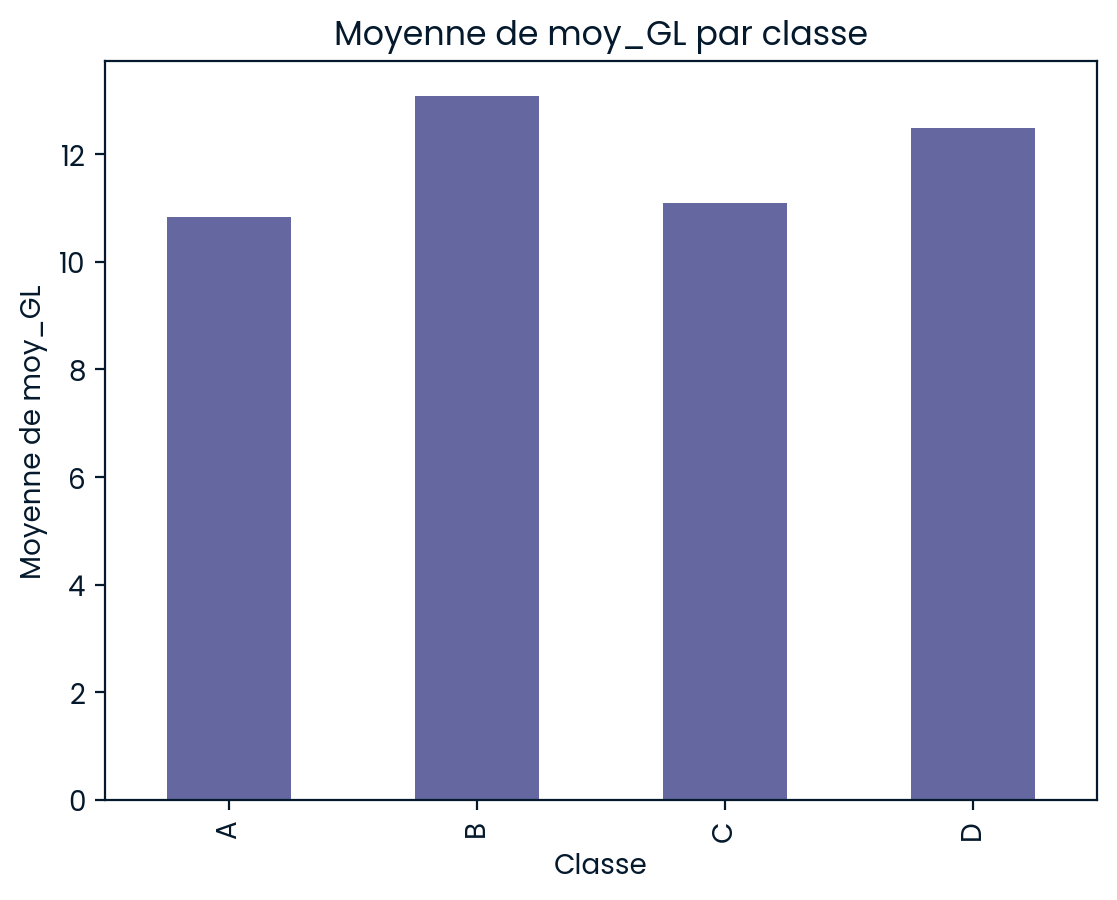

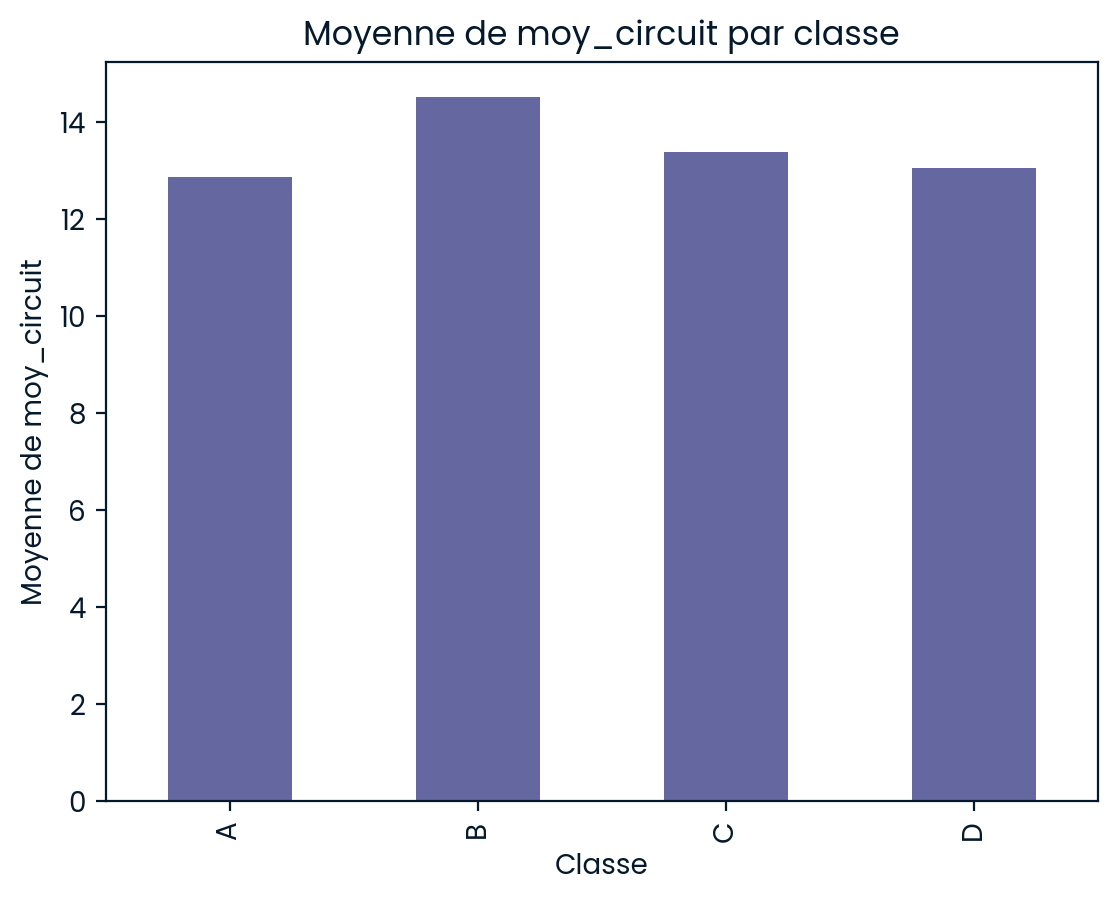

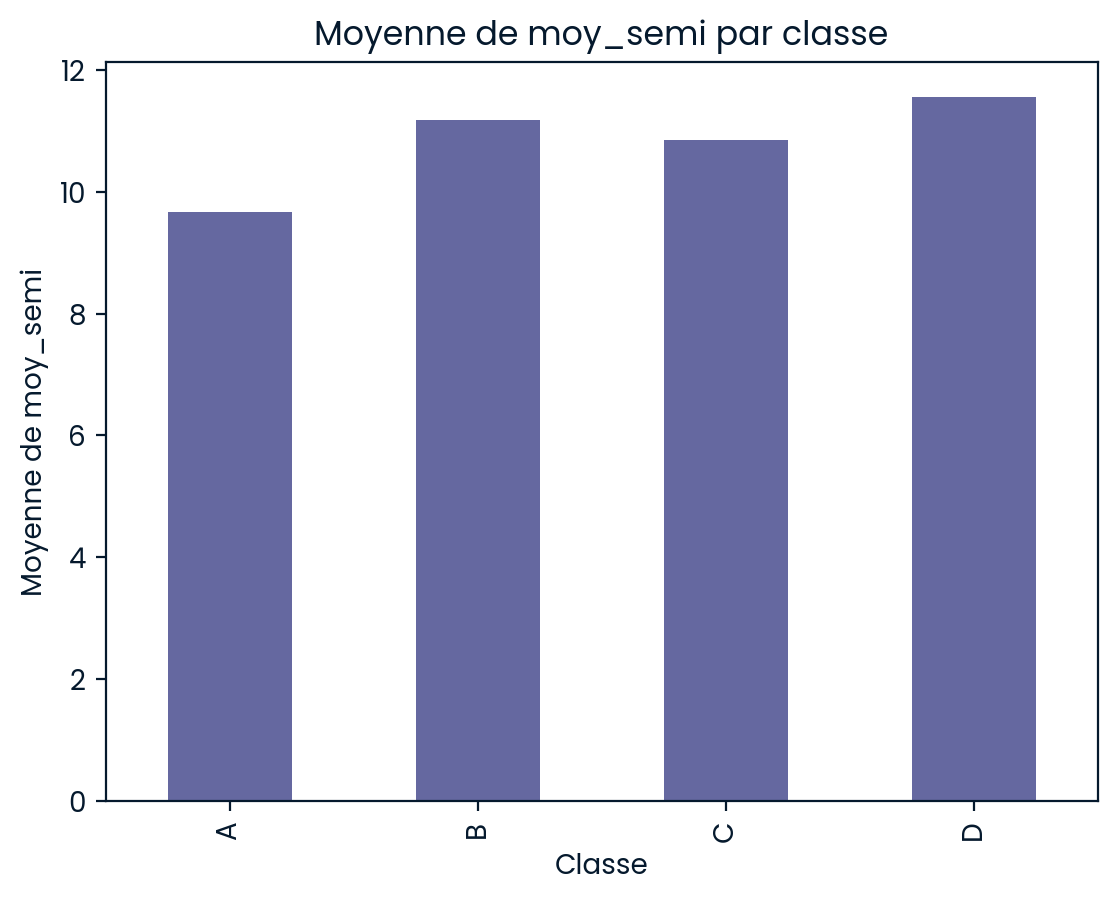

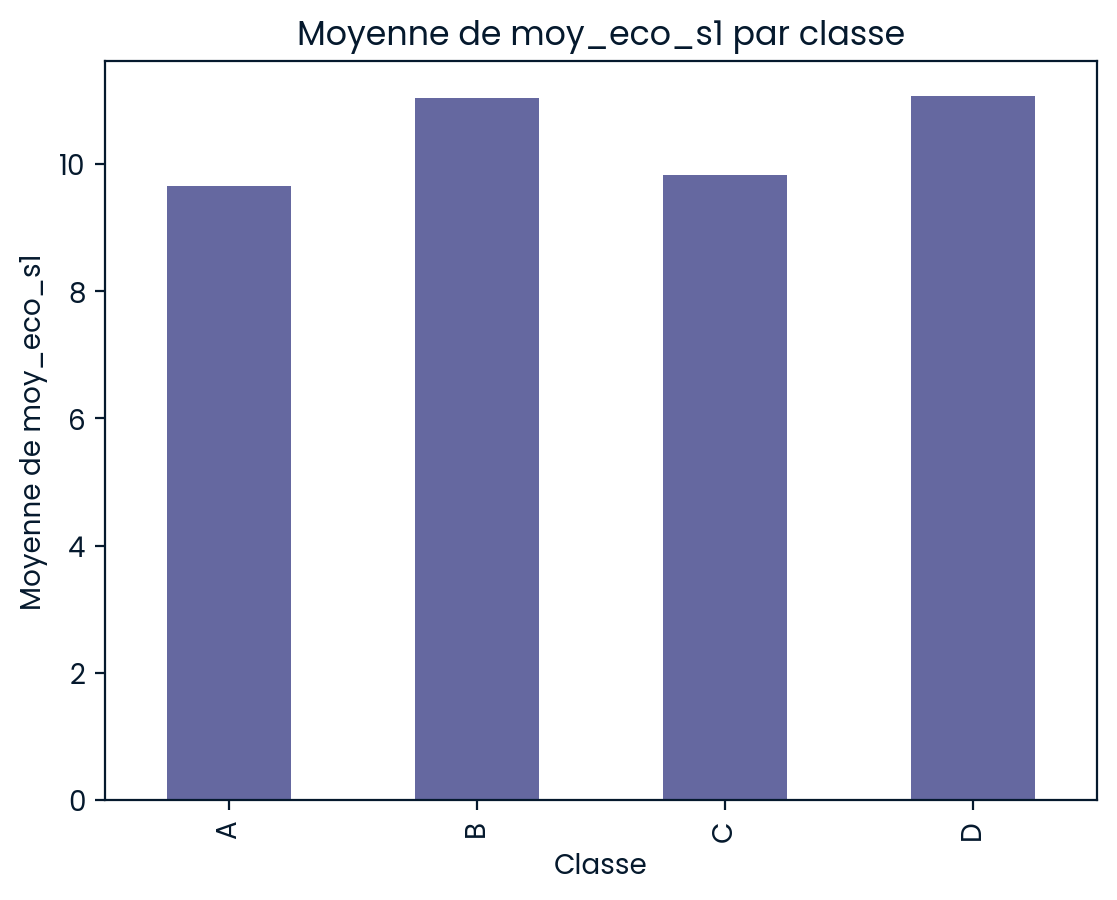

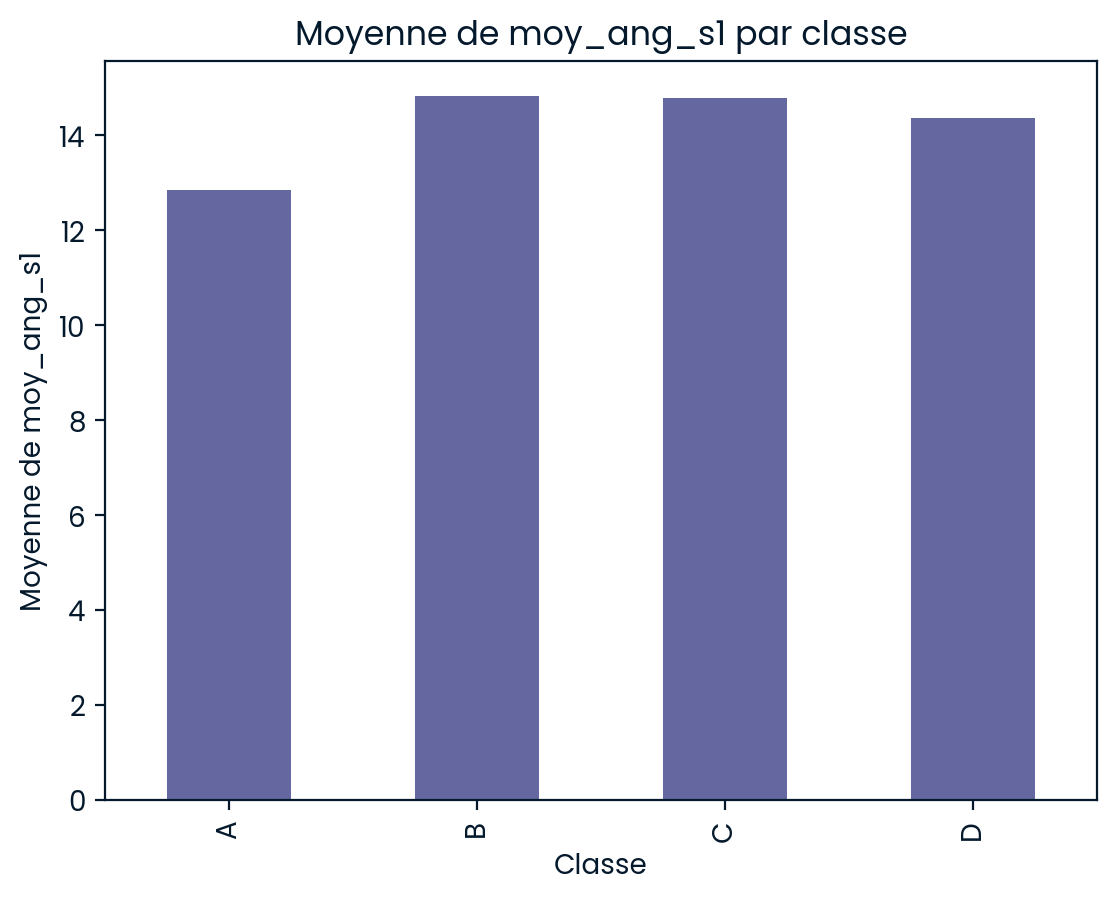

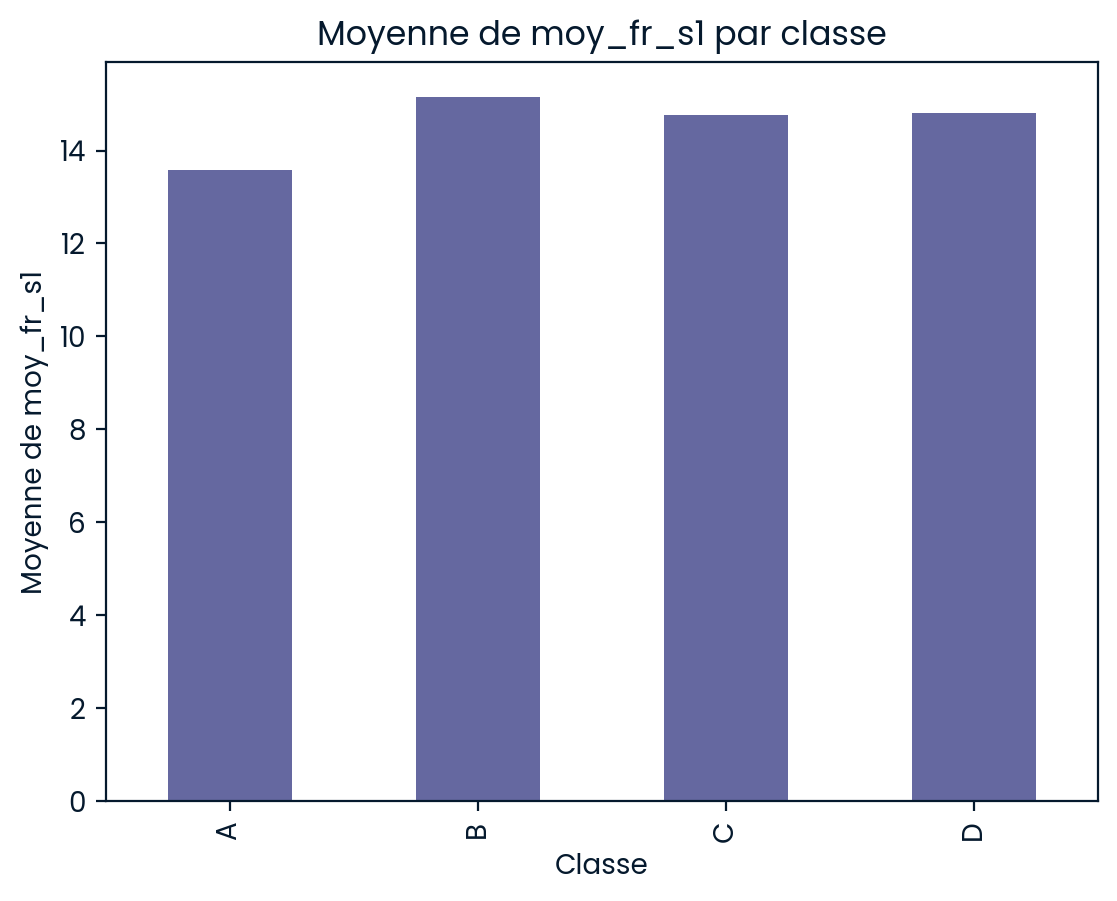

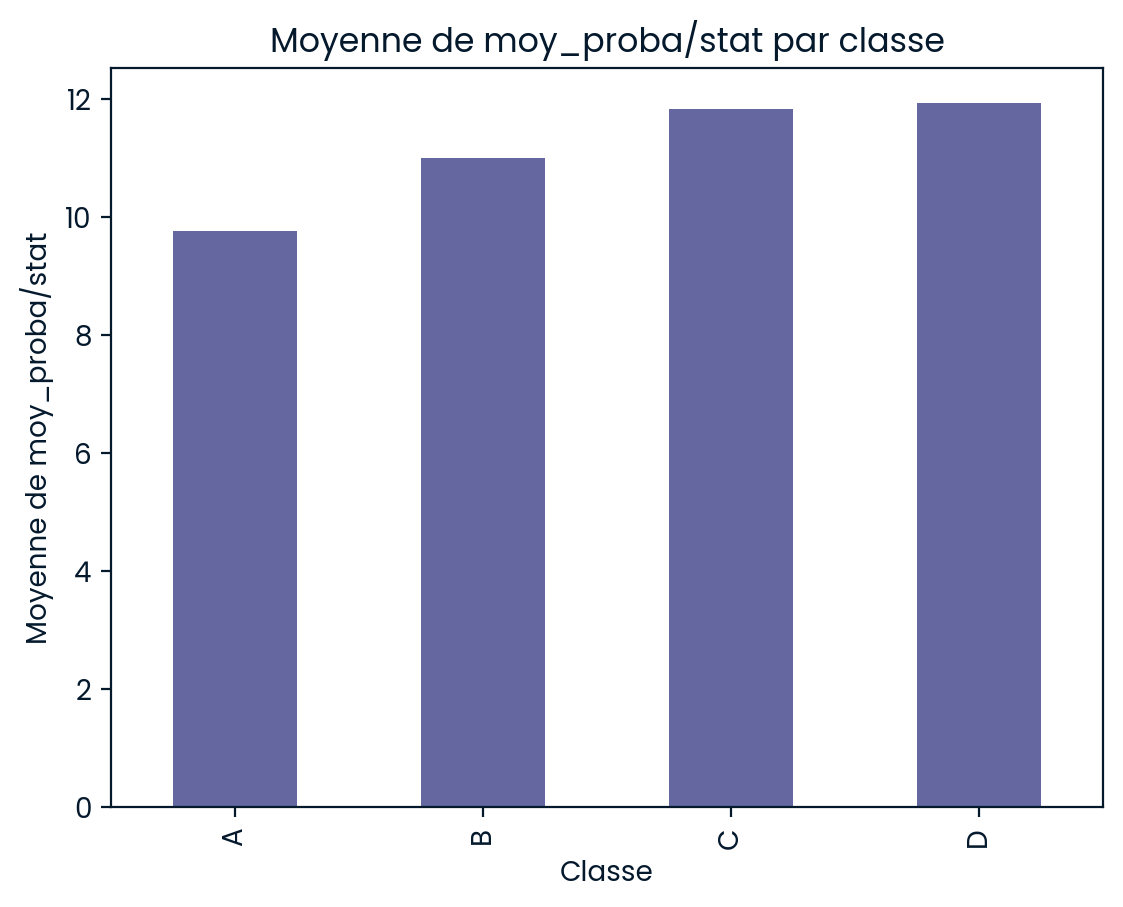

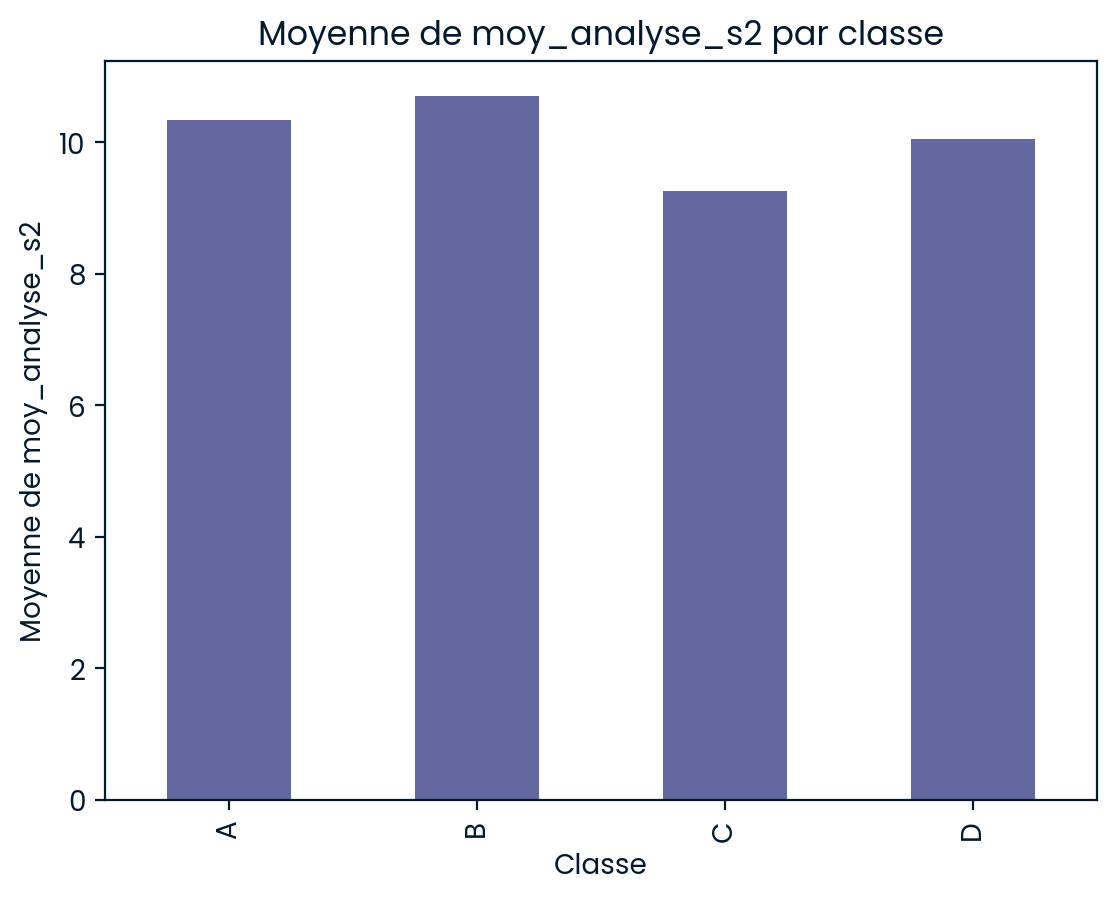

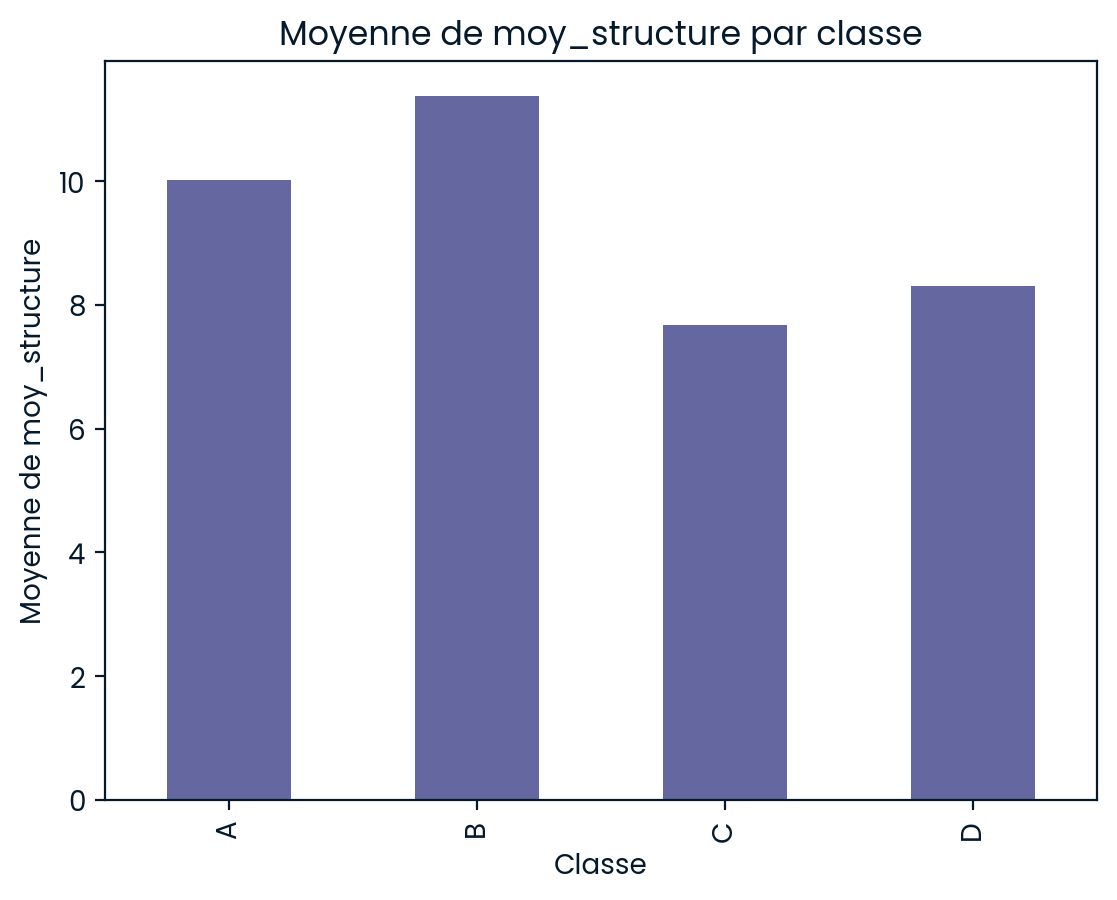

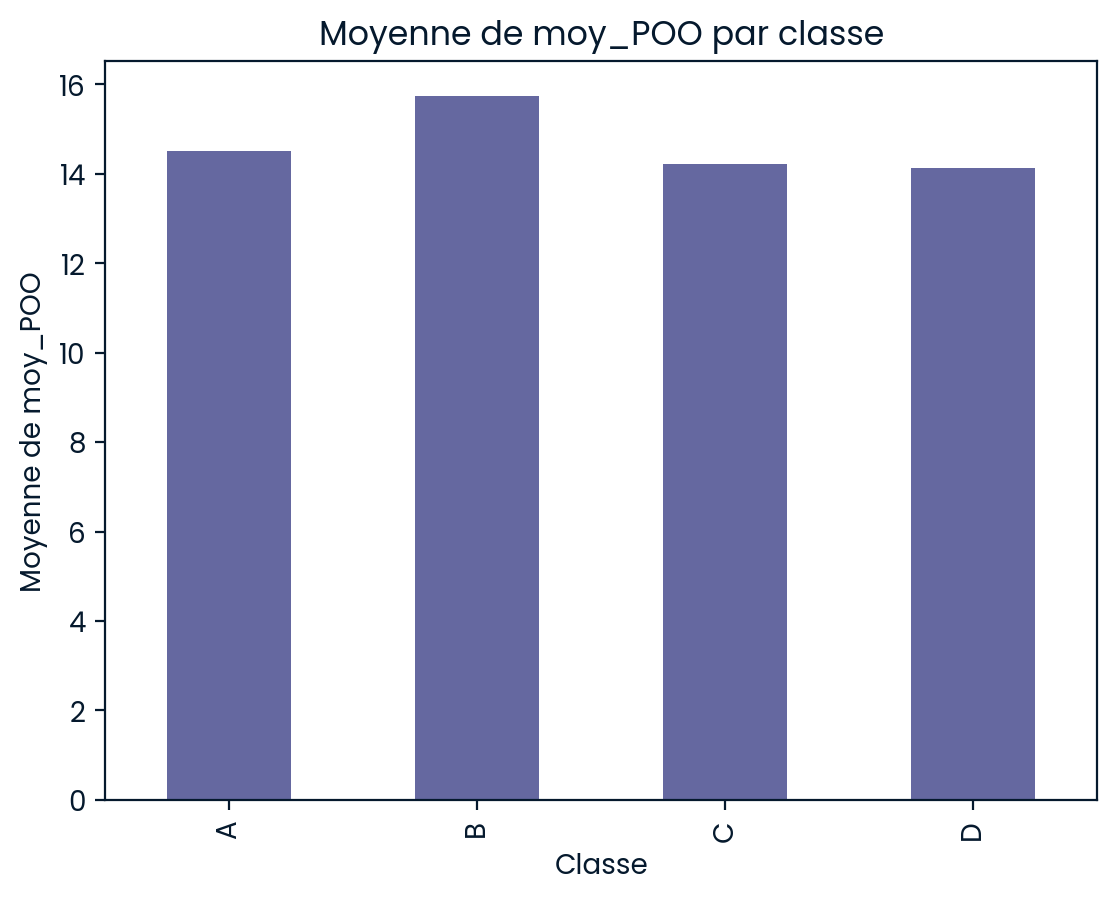

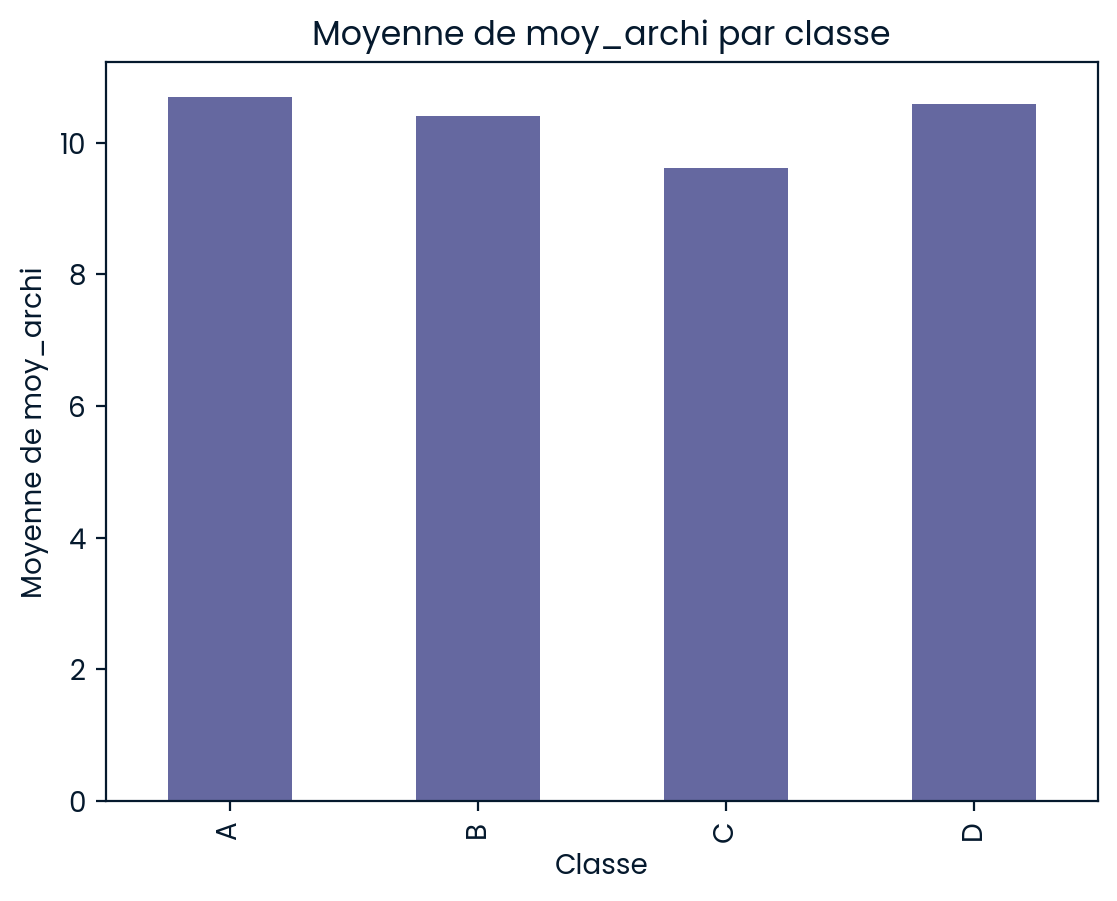

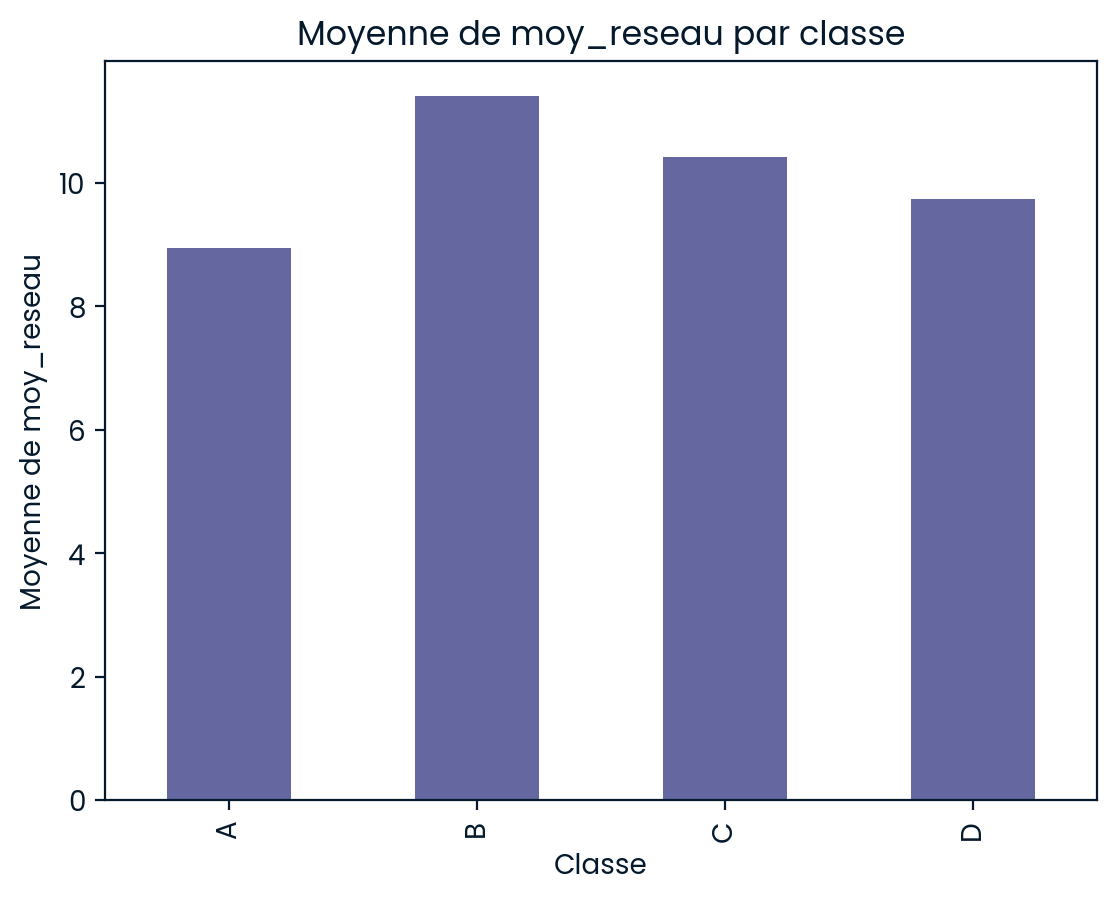

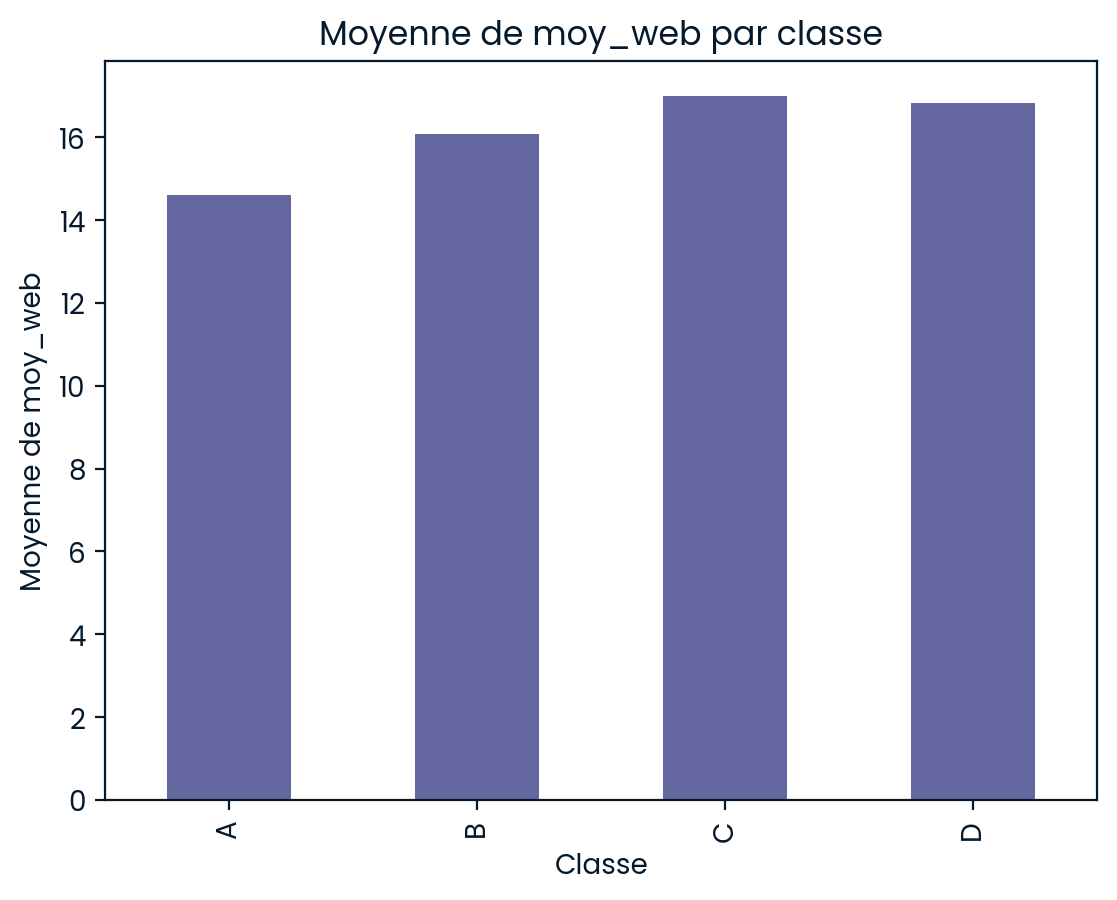

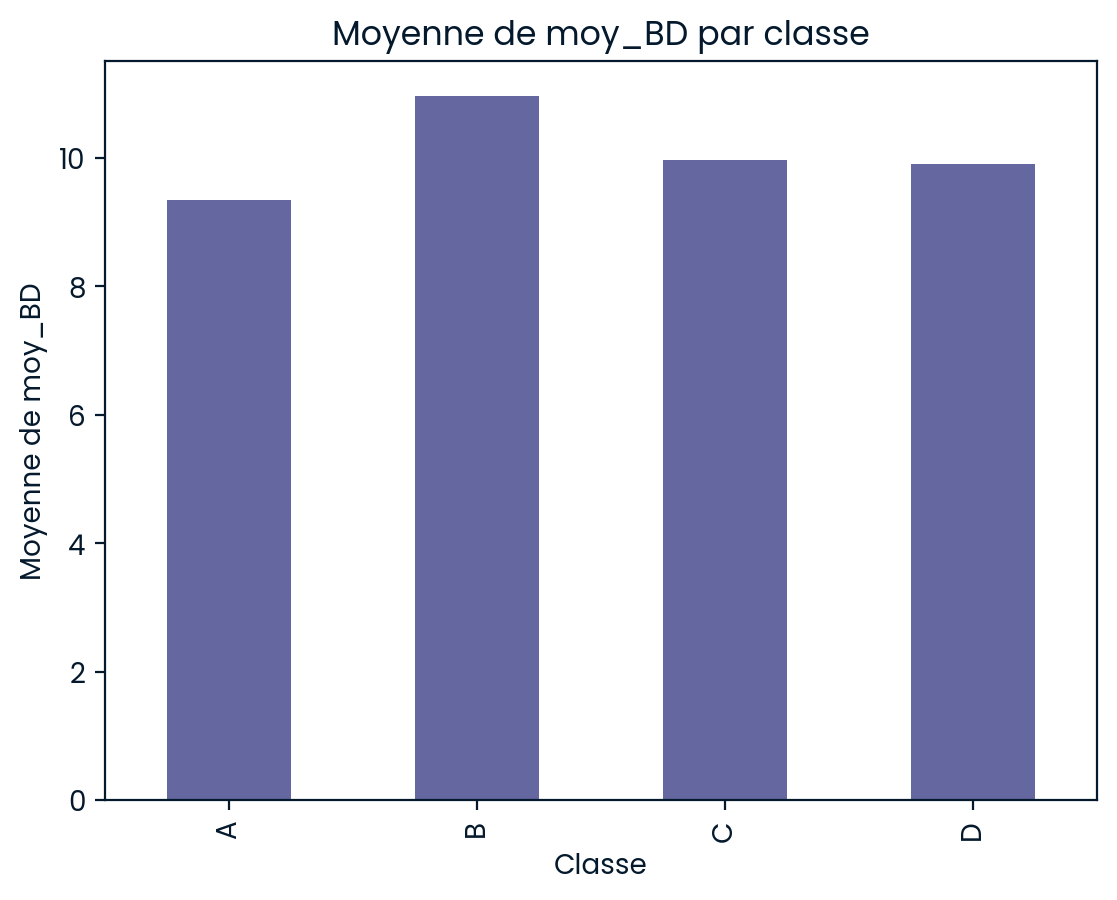

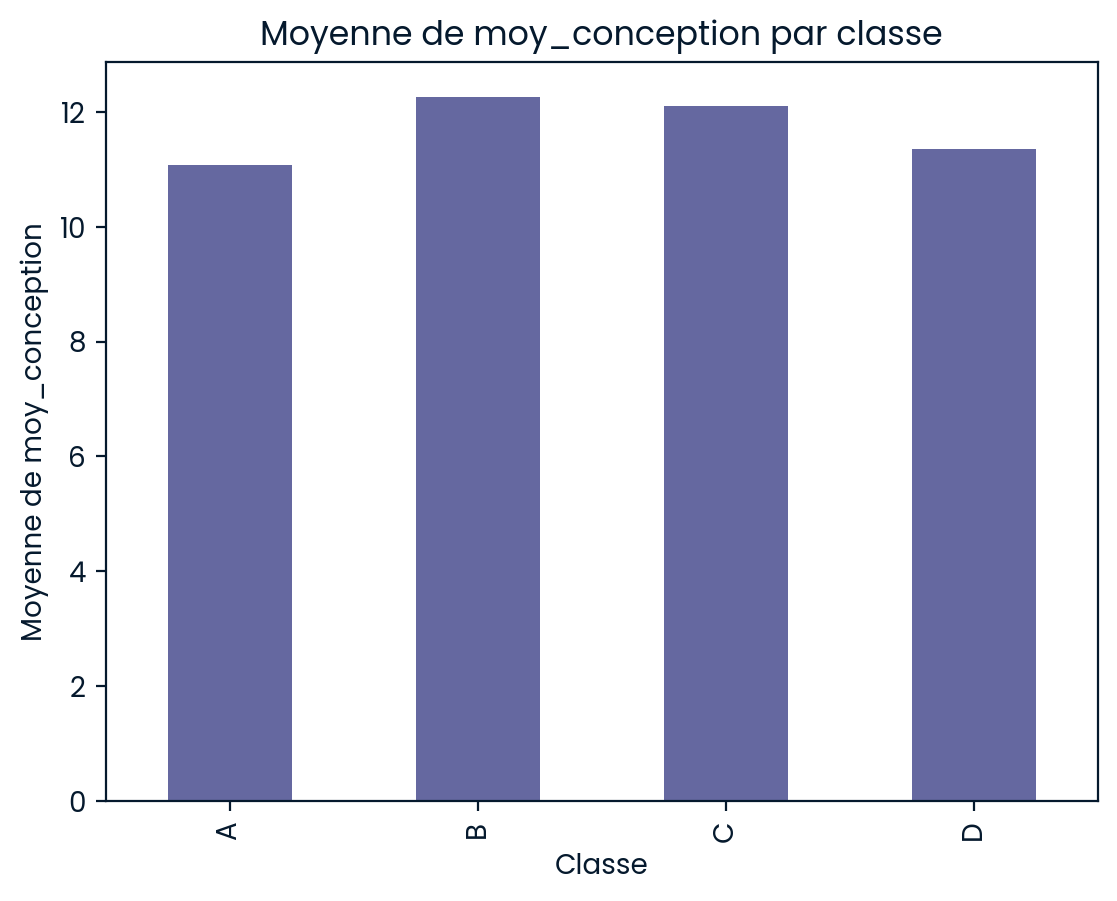

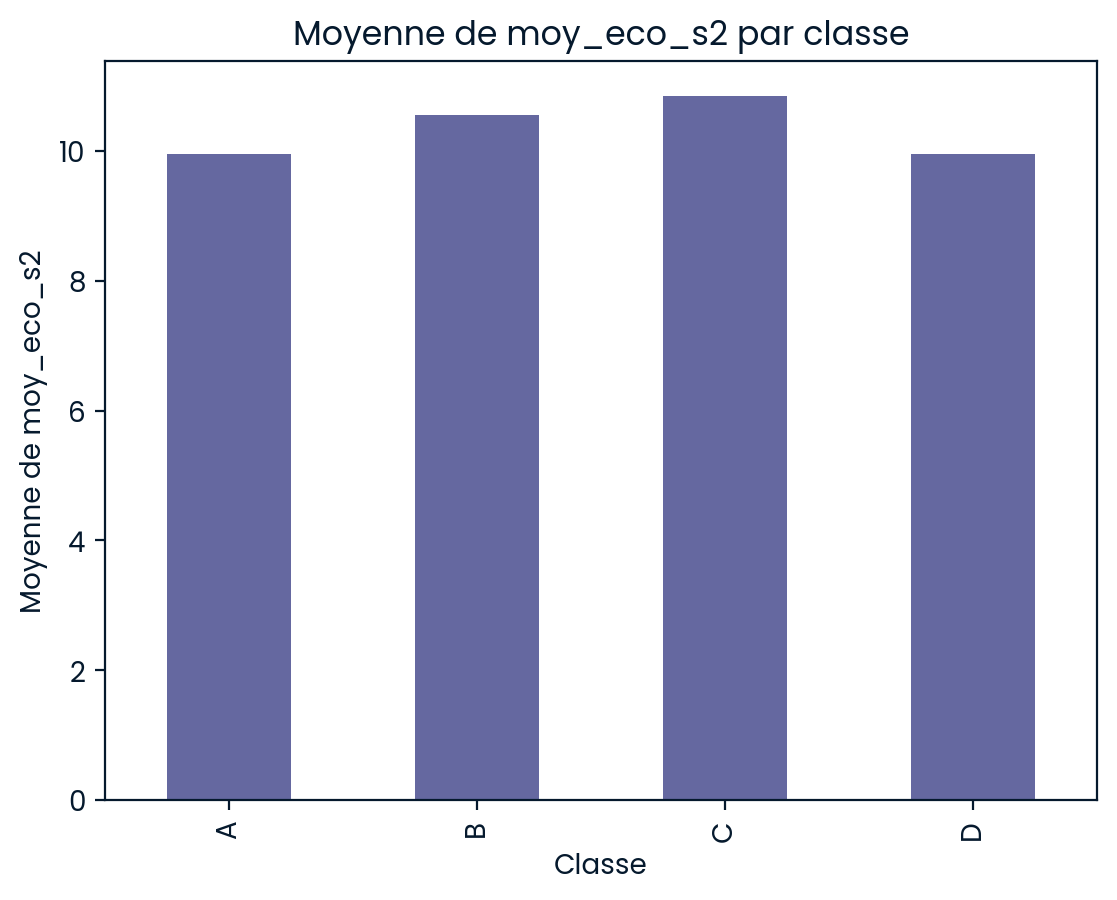

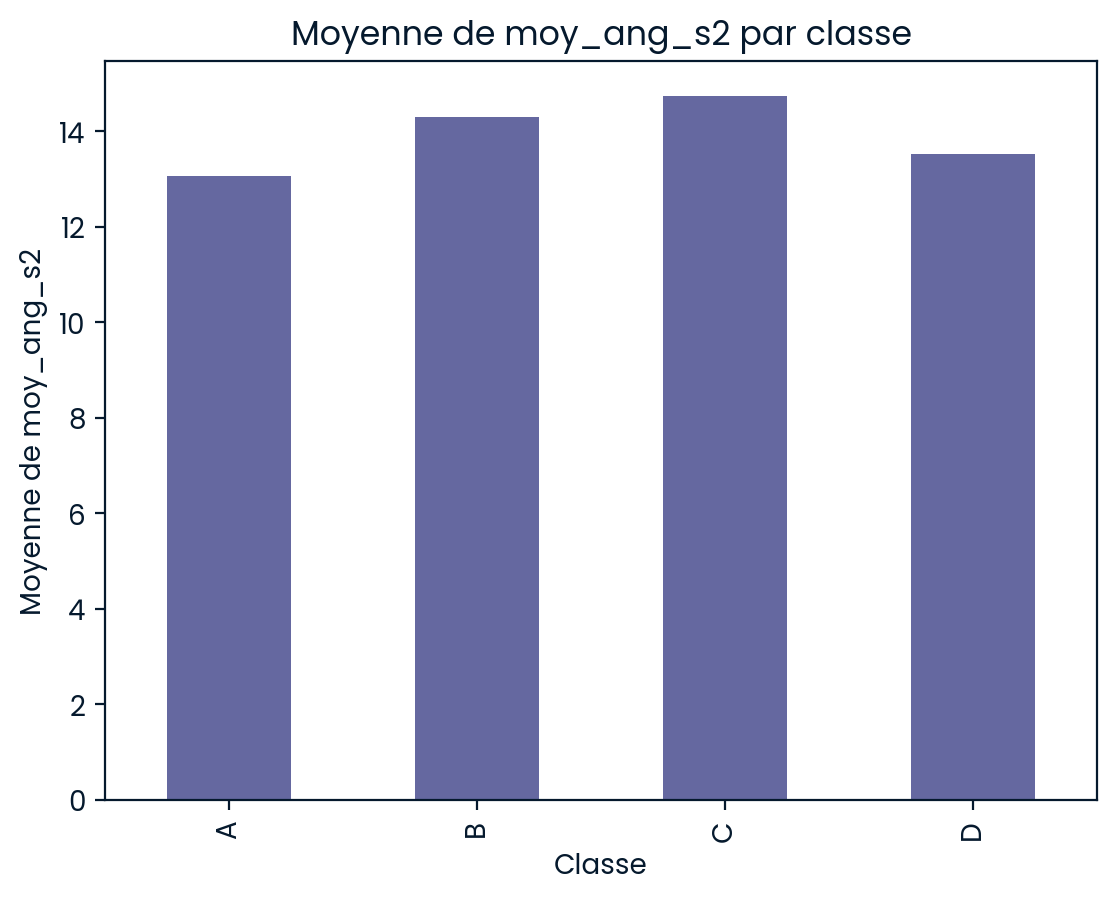

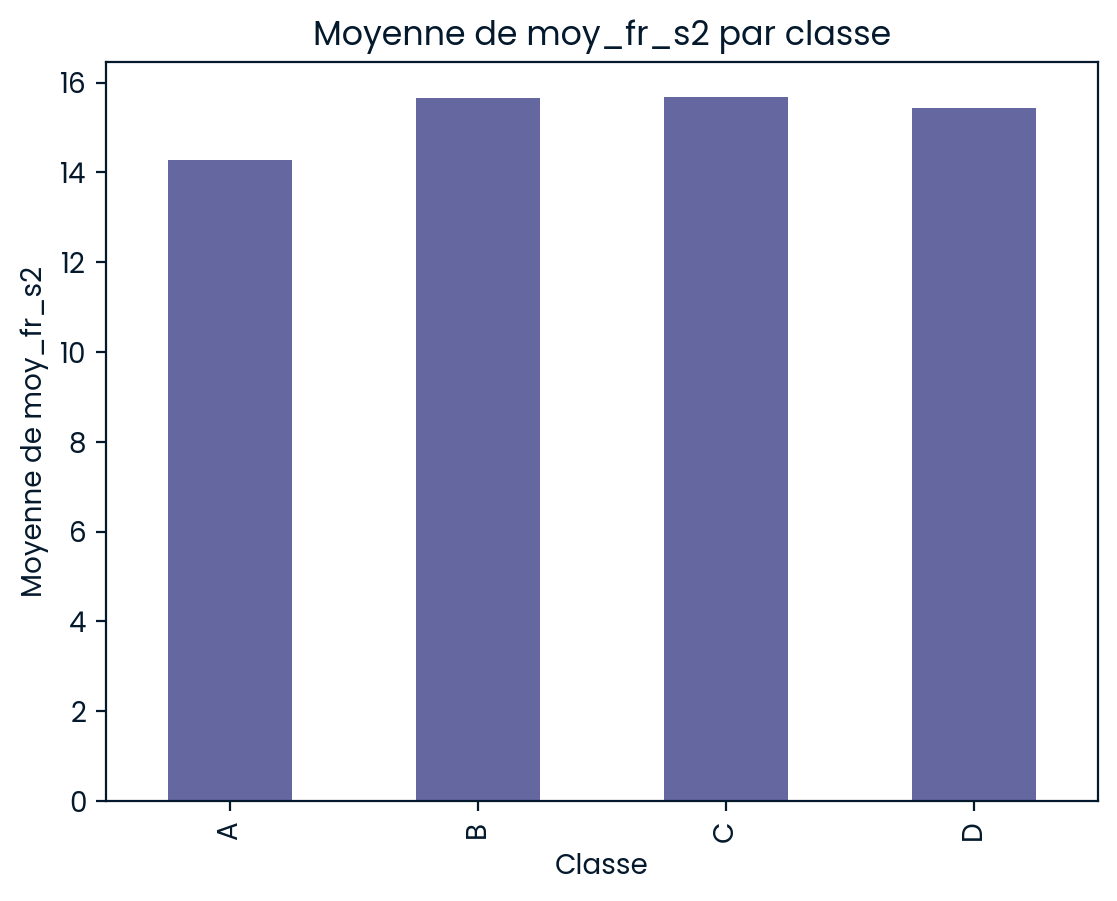

In [12]:
columns = list(info_1ere.columns)
last_column = columns.pop(-1)
columns.insert(3, last_column)
info_1ere = info_1ere[columns]
info_1ere.to_csv("Info_1ere.csv")
info_1ere.groupby('Classe')['moyenne_annuelle'].mean().plot(kind='bar',xlabel='Classe', ylabel='Moyenne annuelle', title='Moyenne annuelle par classe')
plt.show()
for i in info_1ere.columns:
    if i.startswith('moy_'):
        info_1ere.groupby('Classe')[i].mean().plot(kind='bar')
        plt.xlabel('Classe')
        plt.ylabel('Moyenne de {}'.format(i))
        plt.title('Moyenne de {} par classe'.format(i))
        plt.show()

In [13]:
info_1ere["reussite"] = np.where(info_1ere["moyenne_annuelle"] >= 10, 'A', 'R')
info_1ere["reussite"]=info_1ere["reussite"].map({'A':1,'R':0})

In [14]:
columns = list(info_1ere.columns)
last_column = columns.pop(-1)
columns.insert(4, last_column)
info_1ere=info_1ere[columns]

In [15]:
info_1ere["reussite"].value_counts()

reussite
1    94
0    12
Name: count, dtype: int64

In [44]:
info_1ere.columns

Index(['Ident.', 'Nom', 'Prenom', 'Classe', 'reussite', 'cc_math_ing',
       'exam_math_ing', 'moy_math_ing', 'cc_analyse_s1', 'exam_analyse_s1',
       'moy_analyse_s1', 'cc_algo', 'exam_algo', 'moy_algo', 'cc_prog',
       'exam_prog', 'moy_prog', 'cc_TIC', 'exam_TIC', 'moy_TIC', 'cc_logique',
       'exam_logique', 'moy_logique', 'cc_GL', 'exam_GL', 'moy_GL',
       'cc_circuit', 'exam_circuit', 'moy_circuit', 'cc_semi', 'exam_semi',
       'moy_semi', 'cc_eco_s1', 'exam_eco_s1', 'moy_eco_s1', 'cc_ang_s1',
       'exam_ang_s1', 'moy_ang_s1', 'cc_fr_s1', 'exam_fr_s1', 'moy_fr_s1',
       'cc_proba/stat', 'exam_proba/stat', 'moy_proba/stat', 'cc_analyse_s2',
       'exam_analyse_s2', 'moy_analyse_s2', 'cc_structure', 'exam_structure',
       'moy_structure', 'cc_POO', 'exam_POO', 'moy_POO', 'cc_archi',
       'exam_archi', 'moy_archi', 'cc_reseau', 'exam_reseau', 'moy_reseau',
       'cc_web', 'exam_web', 'moy_web', 'cc_BD', 'exam_BD', 'moy_BD',
       'cc_conception', 'exam_concepti

In [55]:
X=info_1ere[[feature for feature in info_1ere.columns[6:columns.index('cc_proba/stat')] if feature.startswith('moy_')]]
X

,moy_math_ing,moy_analyse_s1,moy_algo,moy_prog,moy_TIC,moy_logique,moy_GL,moy_circuit,moy_semi,moy_eco_s1,moy_ang_s1,moy_fr_s1
0,8.65,11.98,11.10,15.13,15.93,13.33,12.20,12.10,10.73,8.43,15.68,13.93
1,5.15,8.33,13.65,15.38,11.20,12.73,15.54,16.39,11.85,12.45,13.54,14.75
2,18.14,10.21,15.83,14.75,13.45,15.83,12.33,16.60,13.28,14.88,16.00,14.73
3,6.95,10.42,12.25,16.88,13.35,14.20,12.45,15.34,12.05,14.05,14.21,14.38
4,5.29,3.40,3.35,11.38,4.88,10.65,10.96,9.10,5.70,8.55,14.95,13.70
...,...,...,...,...,...,...,...,...,...,...,...,...
101,9.19,7.49,12.18,10.25,2.53,10.65,9.00,8.36,4.00,7.45,15.68,14.70
102,11.13,13.63,8.68,12.63,14.30,14.94,12.08,16.23,11.83,6.10,14.70,15.73
103,11.65,9.54,7.00,10.38,8.75,10.53,13.59,9.91,11.60,9.03,15.73,13.05
104,2.10,2.66,5.95,9.38,2.80,4.94,5.69,5.60,2.10,3.85,5.95,5.95


In [18]:
y=info_1ere.reussite
y

0      1
1      1
2      1
3      1
4      0
      ..
101    0
102    1
103    1
104    0
105    1
Name: reussite, Length: 106, dtype: int64

In [ ]:
X_train, X_test, y_train, y_test=train_test_split(X,y,random_state=42,stratify=y,test_size=0.2)
model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
hazem=info_1ere[info_1ere["Prenom"]=='HAZEM']
hazem_pred=model.predict(hazem[[feature for feature in hazem.columns[6:columns.index('cc_proba/stat')] if feature.startswith('moy_')]])
hazem_pred[0]
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["No success", "Success"], yticklabels=["No Success", "Success"])
plt.xlabel("Prediction")
plt.ylabel("Reality")
plt.title("Confusion Matrix")
plt.show()

1